In [1]:
import xarray as xr
import os
import numpy as np
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmc
import glob
import re

retrieval_filename = "../../../DataStorage/AWS/l2_cloud_signal/l2_cloud_signal_20250604231424_20250605005329.nc"
retrieval_ds = xr.open_dataset(retrieval_filename)

datetime_str = retrieval_filename[-32:-3]


In [2]:
def create_plot(cloud_mask_AWS33, cs_ds, ds_MTG, surface_mask, i, step):

    fig, axes = plt.subplots(1, 2, figsize=(32, 12), subplot_kw={"projection": ccrs.PlateCarree()})
    
    
    for ax in axes:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.3, zorder=3)
        ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="white",     zorder=0)
        gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = gl.right_labels = False
        gl.xlabel_style = gl.ylabel_style = {'size': 16}

        ax.set_extent([
            np.nanmin(cs_ds.longitude[i:i + step].values),
            np.nanmax(cs_ds.longitude[i:i + step].values),
            np.nanmin(cs_ds.latitude[i:i + step].values),
            np.nanmax(cs_ds.latitude[i:i + step].values),
        ])
    
    sc = axes[0].scatter(
        cs_ds.longitude[i:i + step].values[cloud_mask_AWS33],
        cs_ds.latitude[i:i + step].values[cloud_mask_AWS33], 
        s=5, zorder=1, c="blue",
    )

    if (surface_mask.any()):
        axes[0].scatter(
            cs_ds.longitude[i:i + step].values[surface_mask],
            cs_ds.latitude[i:i + step].values[surface_mask],
            c="red", s=5, ec="None", label="Surface impact", zorder=0,
        )
        ax.legend()
        

    masked_phase, extent, geo_proj = setup_mtg(ds_MTG)
    
    axes[1].imshow(
        masked_phase, origin="upper", extent=extent,
        transform=geo_proj, cmap="Set3", interpolation="none"
    )
    
    return fig


def setup_mtg(ds_MTG):
    proj_attrs = ds_MTG["mtg_geos_projection"].attrs

    geo_proj = ccrs.Geostationary(
        satellite_height=proj_attrs["perspective_point_height"],
        central_longitude=proj_attrs["longitude_of_projection_origin"],
        sweep_axis=proj_attrs["sweep_angle_axis"],
        globe=ccrs.Globe(
            semimajor_axis=proj_attrs["semi_major_axis"],
            semiminor_axis=proj_attrs["semi_minor_axis"]
        )
    )

    # Prepare the data
    x = ds_MTG["x"].values[::-1]  # radians
    y = ds_MTG["y"].values  # radians
    cloud_phase = ds_MTG["retrieved_cloud_phase"].values[::-1, :]  # shape (y, x)

    # filter for only ice clouds
    masked_phase = np.ma.masked_where(cloud_phase != 2, cloud_phase)

    # convert angle to metre
    x_m = np.tan(x) * proj_attrs["perspective_point_height"]
    y_m = np.tan(y) * proj_attrs["perspective_point_height"]
    xx, yy = np.meshgrid(x_m, y_m)

    extent = [
        np.tan(x[0]) * proj_attrs["perspective_point_height"],
        np.tan(x[-1]) * proj_attrs["perspective_point_height"],
        np.tan(y[0]) * proj_attrs["perspective_point_height"],
        np.tan(y[-1]) * proj_attrs["perspective_point_height"]
    ]

    return masked_phase, extent, geo_proj

    
def parse_sensing_start(folder_name):
    """Extract sensing start time from folder name, e.g. 20250604231000"""
    match = re.search(r'OPE_(\d{14})_\d{14}', folder_name)
    if match:
        return datetime.strptime(match.group(1), "%Y%m%d%H%M%S")
    return None


def get_closest_MTG(dt):
    """Return the nc file path closest in sensing start time to dt."""
    deltas = np.abs([(t - dt).total_seconds() for t in mtg_times_arr])
    closest = mtg_times_arr[np.argmin(deltas)]
    return mtg_files[closest], closest



/tmp/ipykernel_62127/1350692240.py:18: UserWarning: Discarding nonzero nanoseconds in conversion.
  mid_dt = pd.Timestamp(chunk[len(chunk) // 2]).to_pydatetime()
/tmp/ipykernel_62127/1413913203.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Chunk 0-499 | mid: 2025-06-04 23:19:03.673787 | MTG: 2025-06-04 23:20:00 | ../../../DataStorage/MTG/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD--x-x---x_C_EUMT_20250604233710_L2PF_OPE_20250604232000_20250604233000_N__C_0141_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD------NC4E_C_EUMT_20250604233540_L2PF_OPE_20250604232000_20250604233000_N__C_0141_0000.nc


/tmp/ipykernel_62127/1350692240.py:18: UserWarning: Discarding nonzero nanoseconds in conversion.
  mid_dt = pd.Timestamp(chunk[len(chunk) // 2]).to_pydatetime()
/tmp/ipykernel_62127/1413913203.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Chunk 500-999 | mid: 2025-06-04 23:28:58.975107 | MTG: 2025-06-04 23:30:00 | ../../../DataStorage/MTG/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD--x-x---x_C_EUMT_20250604234909_L2PF_OPE_20250604233000_20250604234000_N__C_0142_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD------NC4E_C_EUMT_20250604234812_L2PF_OPE_20250604233000_20250604234000_N__C_0142_0000.nc


/tmp/ipykernel_62127/1350692240.py:18: UserWarning: Discarding nonzero nanoseconds in conversion.
  mid_dt = pd.Timestamp(chunk[len(chunk) // 2]).to_pydatetime()


...

Chunk 3500-3999 | mid: 2025-06-05 00:28:30.783610 | MTG: 2025-06-05 00:30:00 | ../../../DataStorage/MTG/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD--x-x---x_C_EUMT_20250605004709_L2PF_OPE_20250605003000_20250605004000_N__C_0004_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD------NC4E_C_EUMT_20250605004439_L2PF_OPE_20250605003000_20250605004000_N__C_0004_0000.nc


/tmp/ipykernel_62127/1350692240.py:18: UserWarning: Discarding nonzero nanoseconds in conversion.
  mid_dt = pd.Timestamp(chunk[len(chunk) // 2]).to_pydatetime()
/tmp/ipykernel_62127/1413913203.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Chunk 4000-4499 | mid: 2025-06-05 00:38:26.085141 | MTG: 2025-06-05 00:40:00 | ../../../DataStorage/MTG/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD--x-x---x_C_EUMT_20250605005657_L2PF_OPE_20250605004000_20250605005000_N__C_0005_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD------NC4E_C_EUMT_20250605005425_L2PF_OPE_20250605004000_20250605005000_N__C_0005_0000.nc


/tmp/ipykernel_62127/1350692240.py:18: UserWarning: Discarding nonzero nanoseconds in conversion.
  mid_dt = pd.Timestamp(chunk[len(chunk) // 2]).to_pydatetime()
/tmp/ipykernel_62127/1413913203.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Chunk 4500-4994 | mid: 2025-06-05 00:48:17.814663 | MTG: 2025-06-05 00:50:00 | ../../../DataStorage/MTG/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD--x-x---x_C_EUMT_20250605010704_L2PF_OPE_20250605005000_20250605010000_N__C_0006_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD------NC4E_C_EUMT_20250605010439_L2PF_OPE_20250605005000_20250605010000_N__C_0006_0000.nc


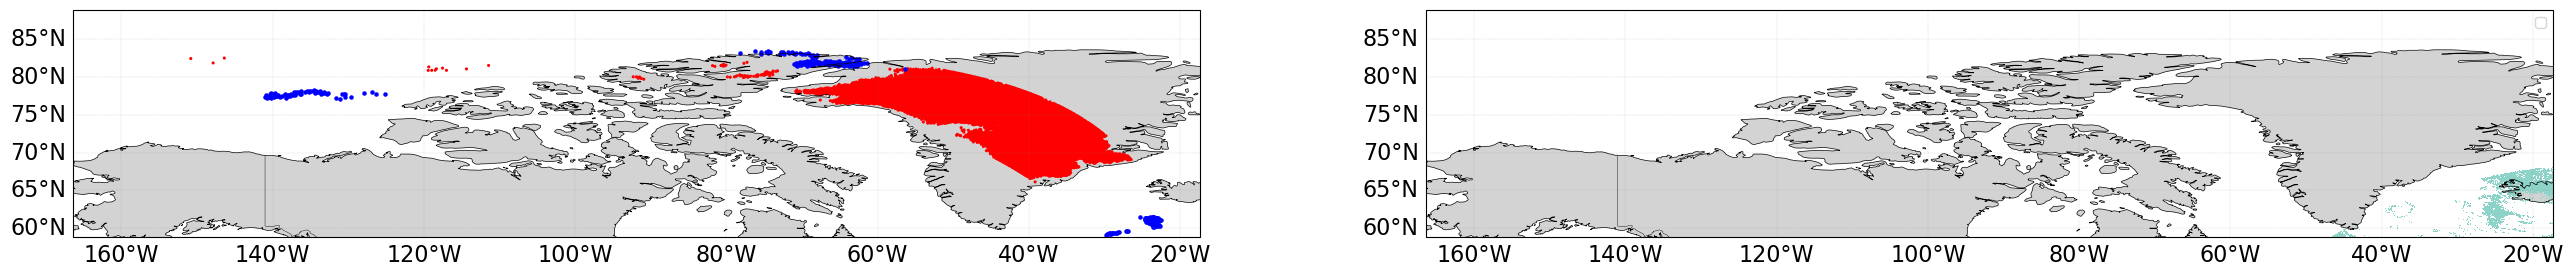

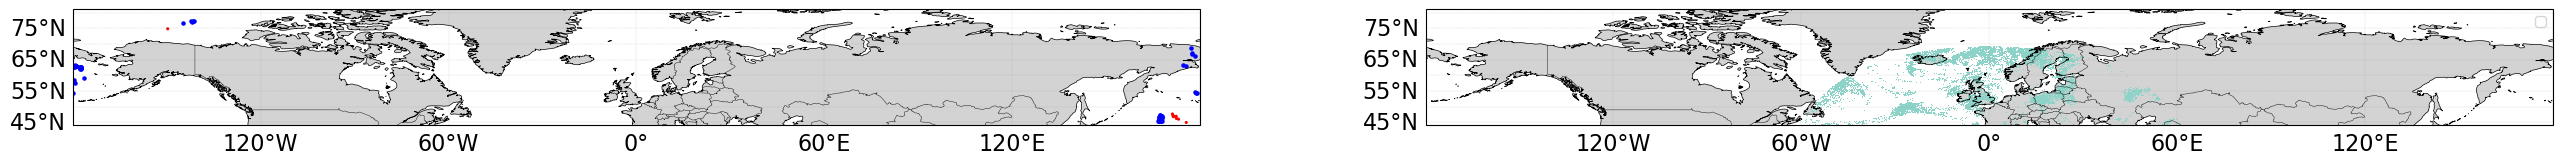

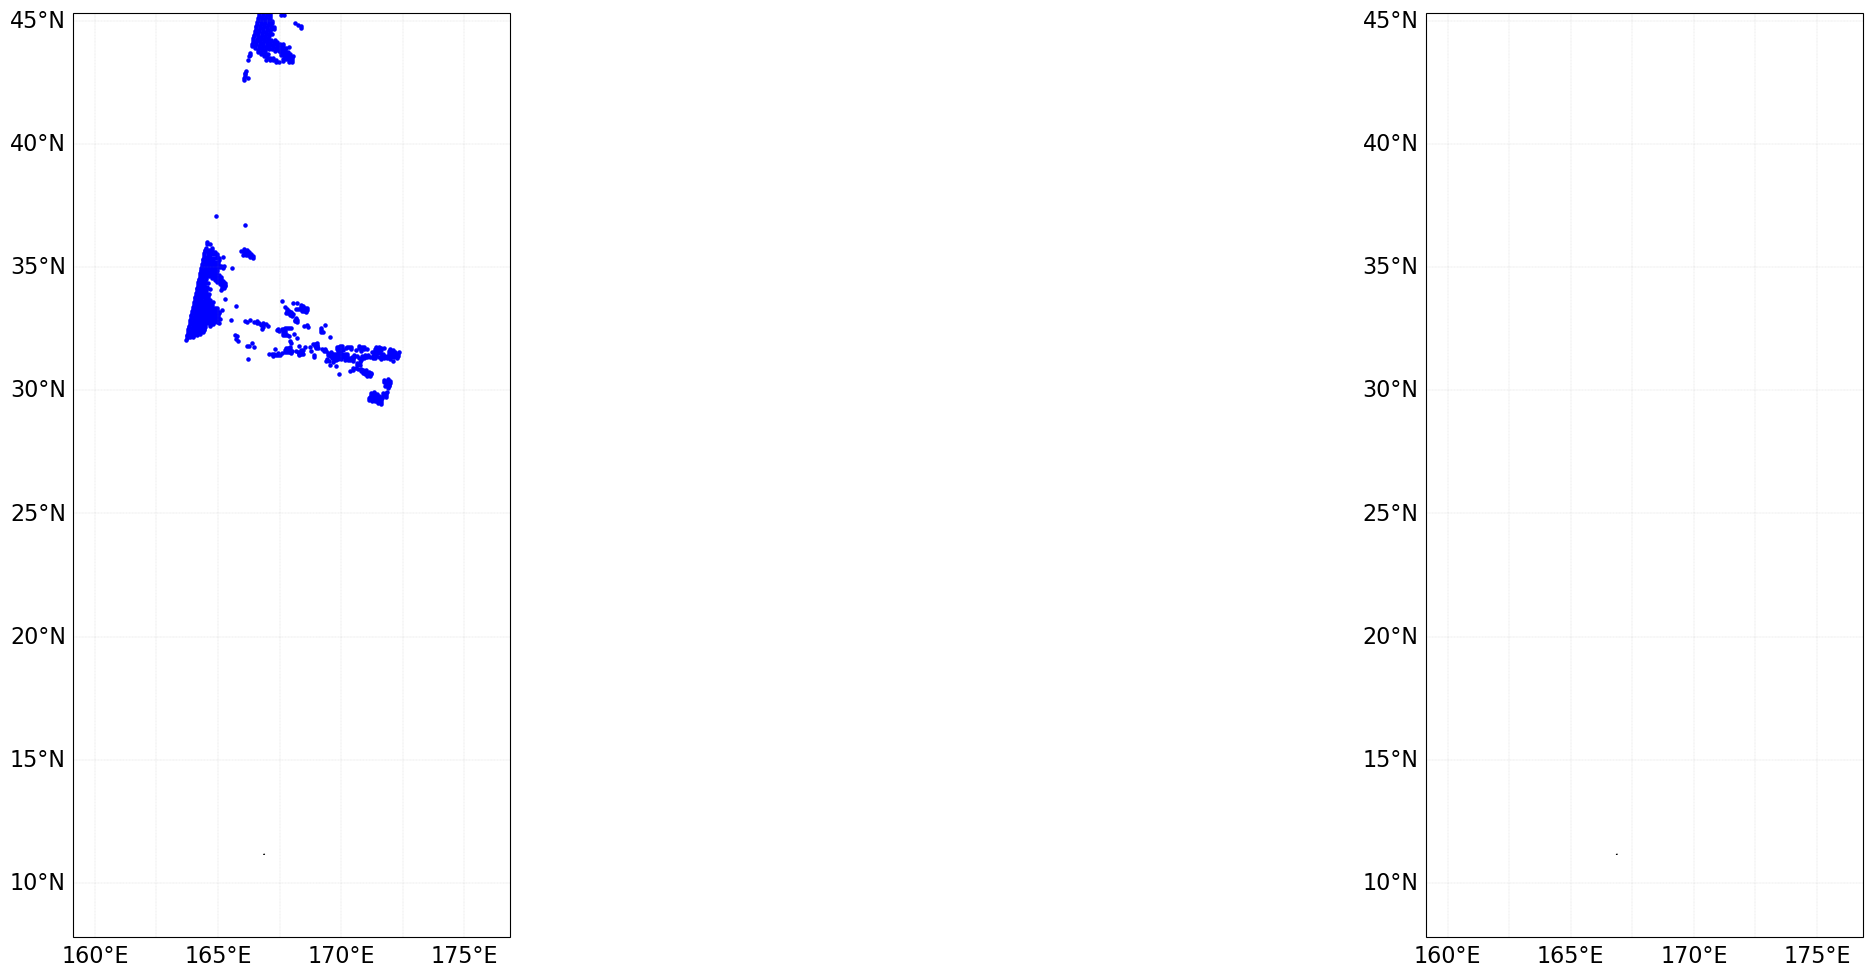

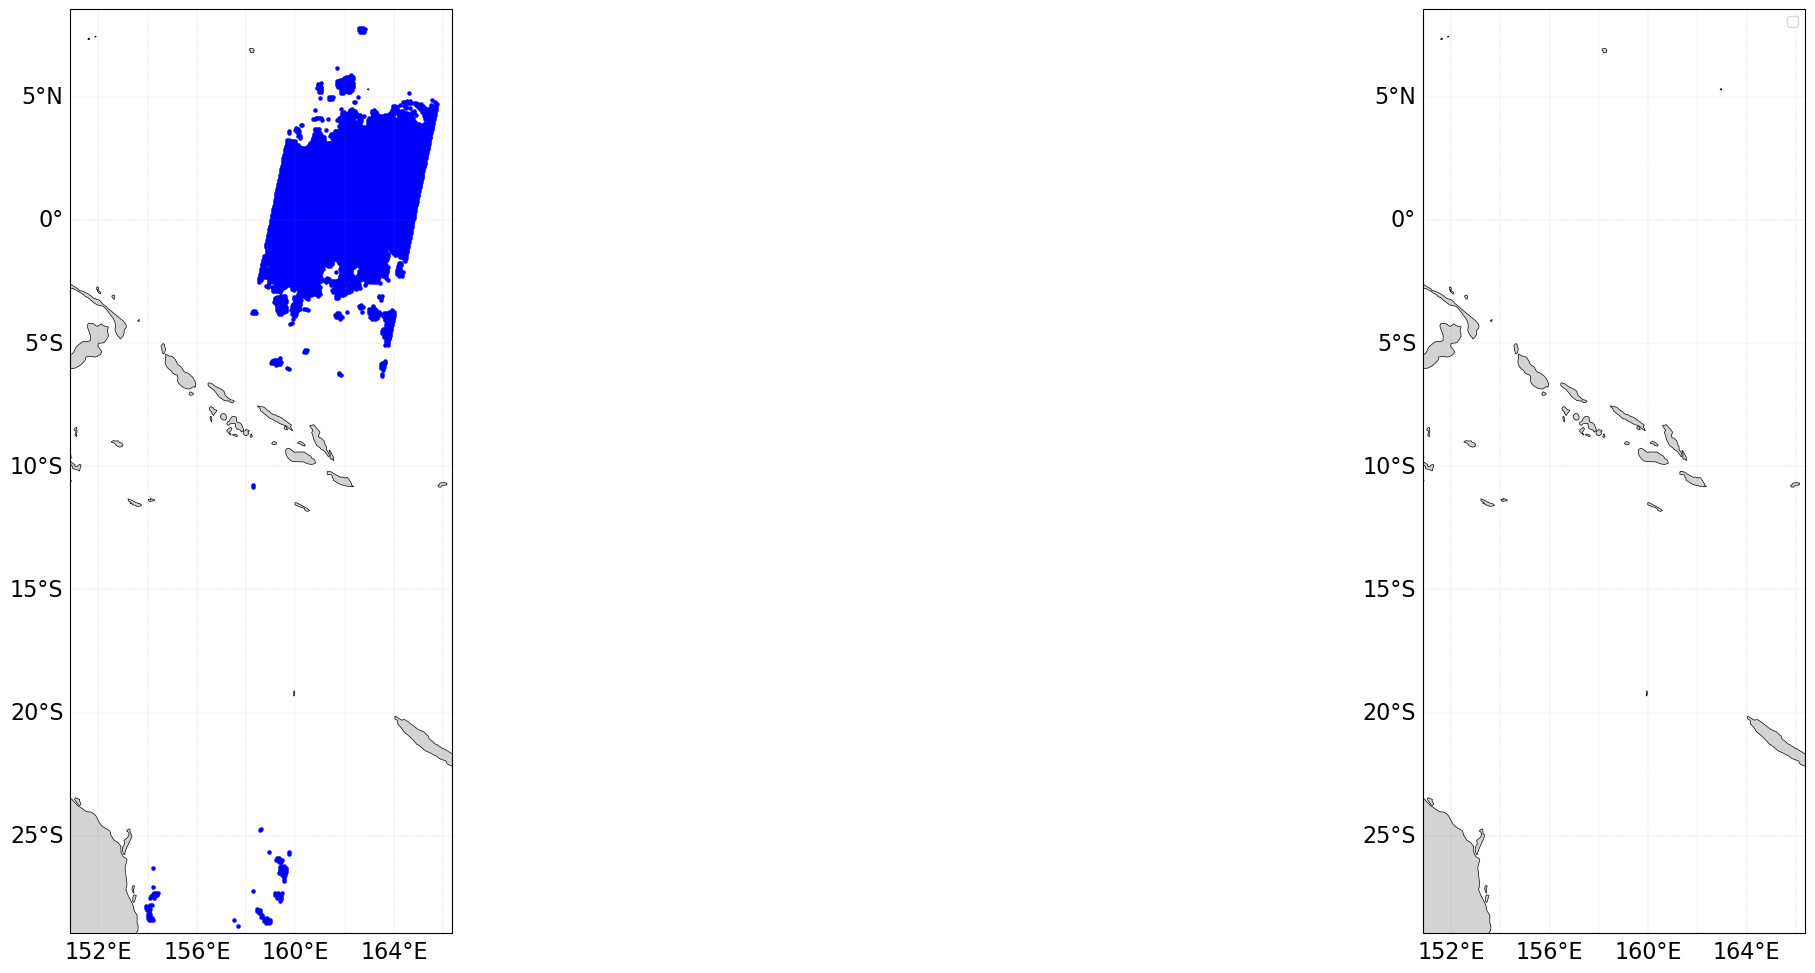

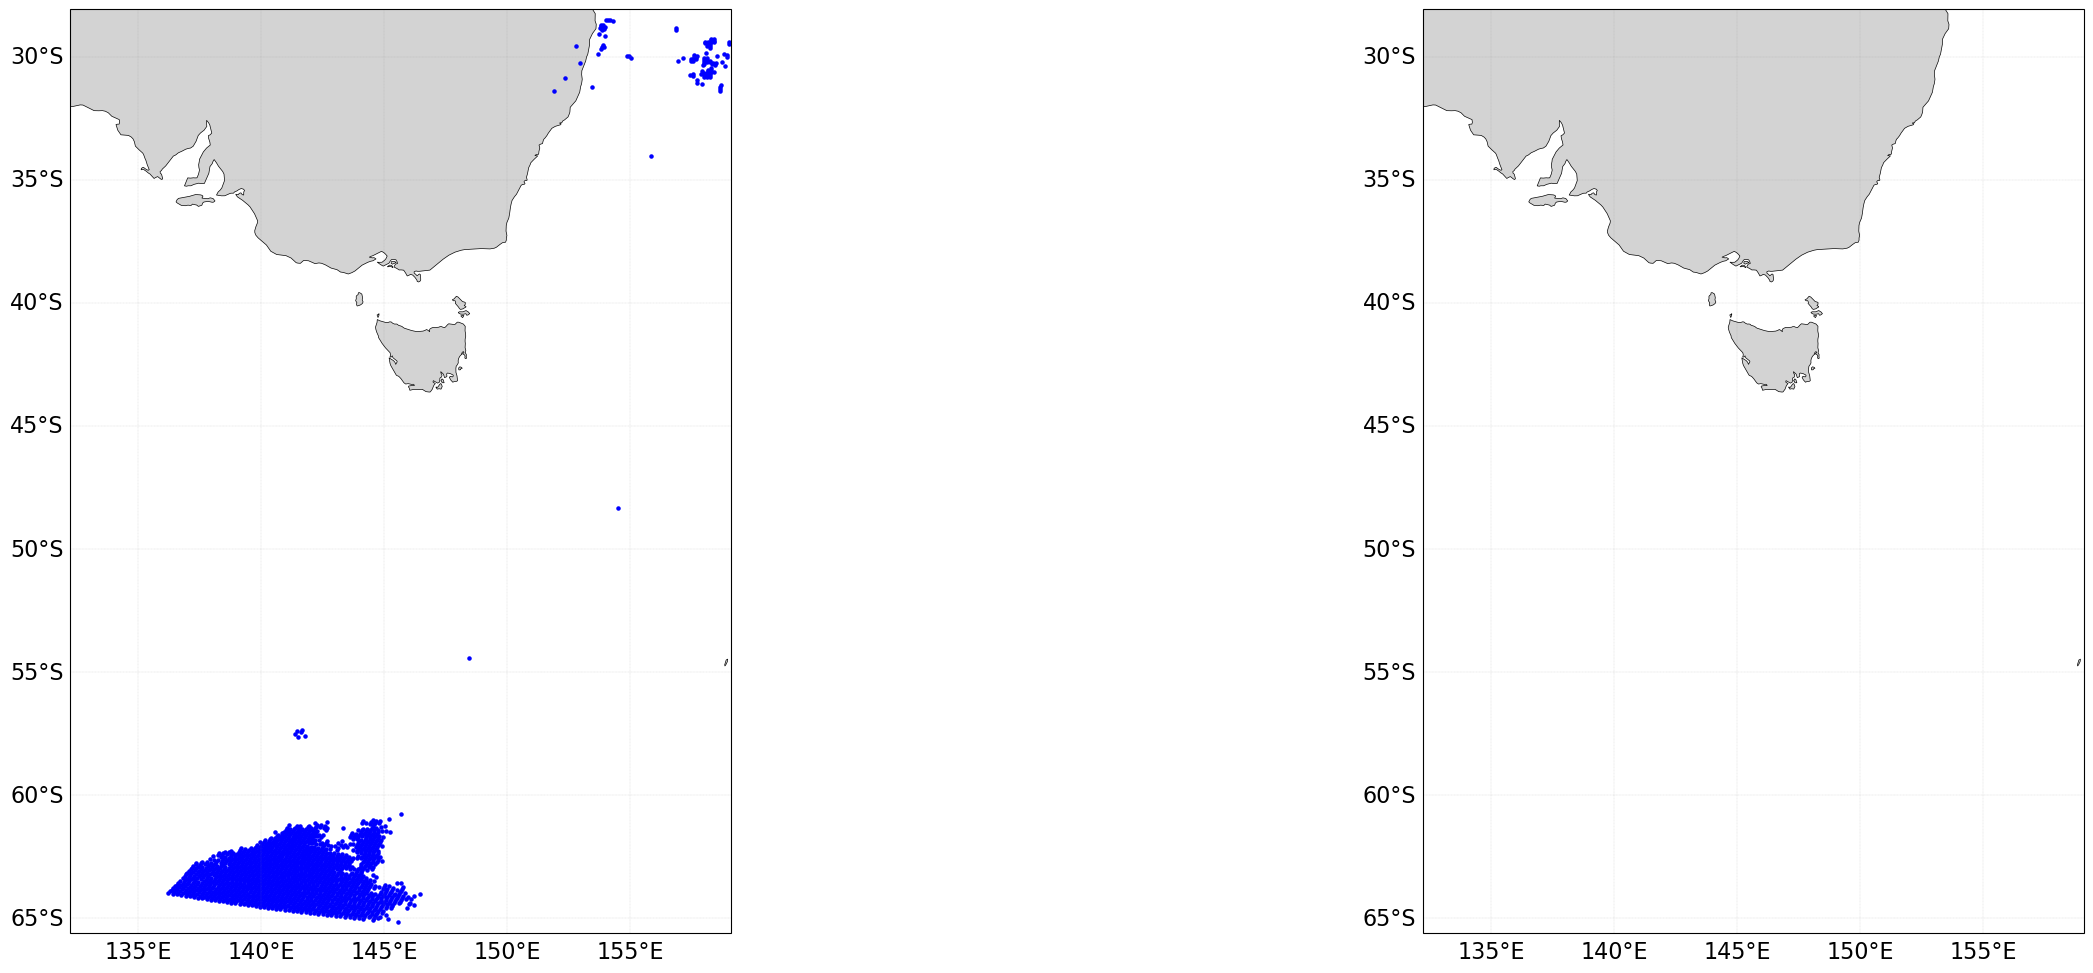

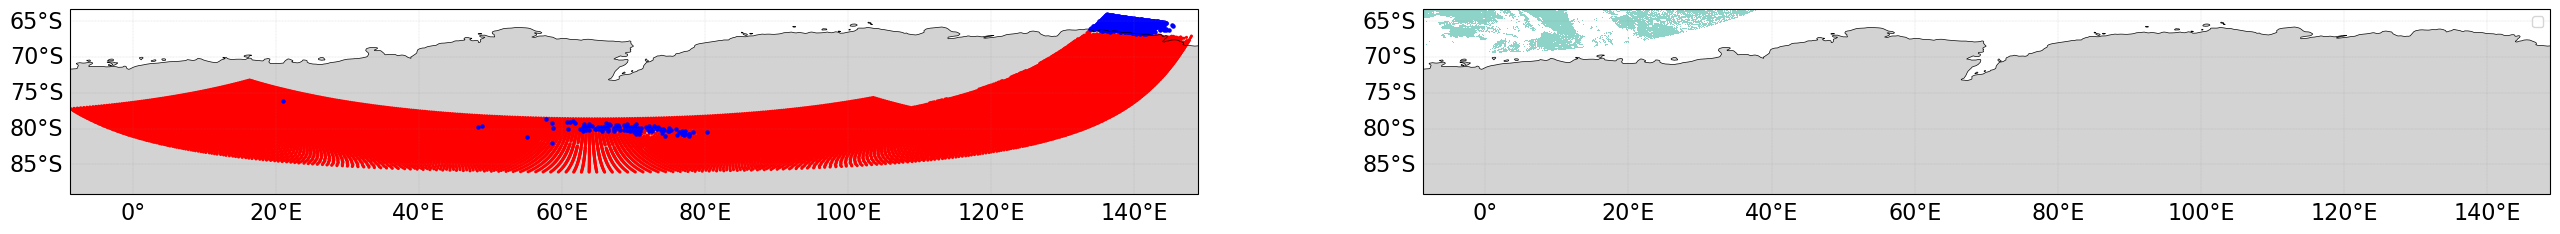

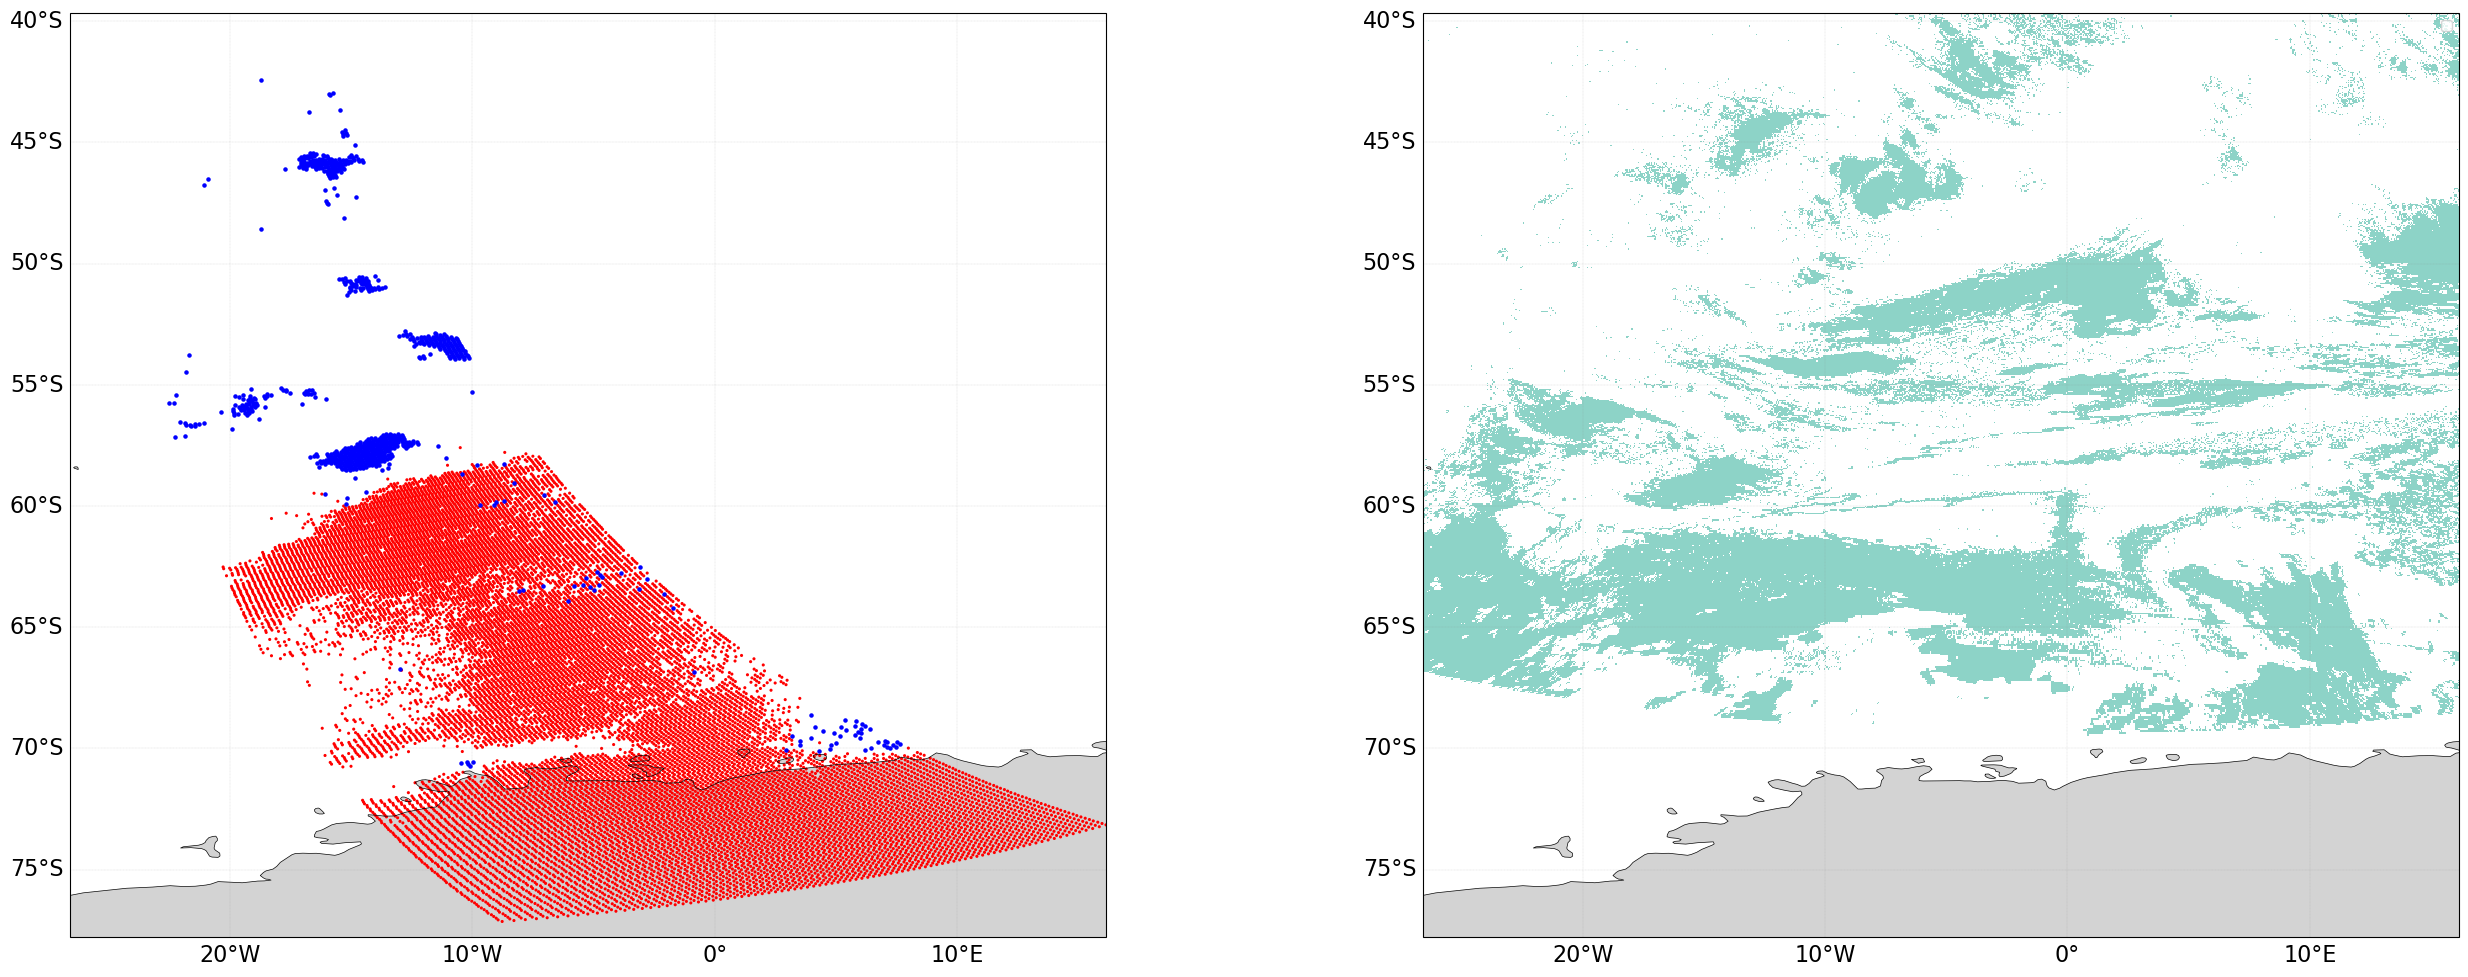

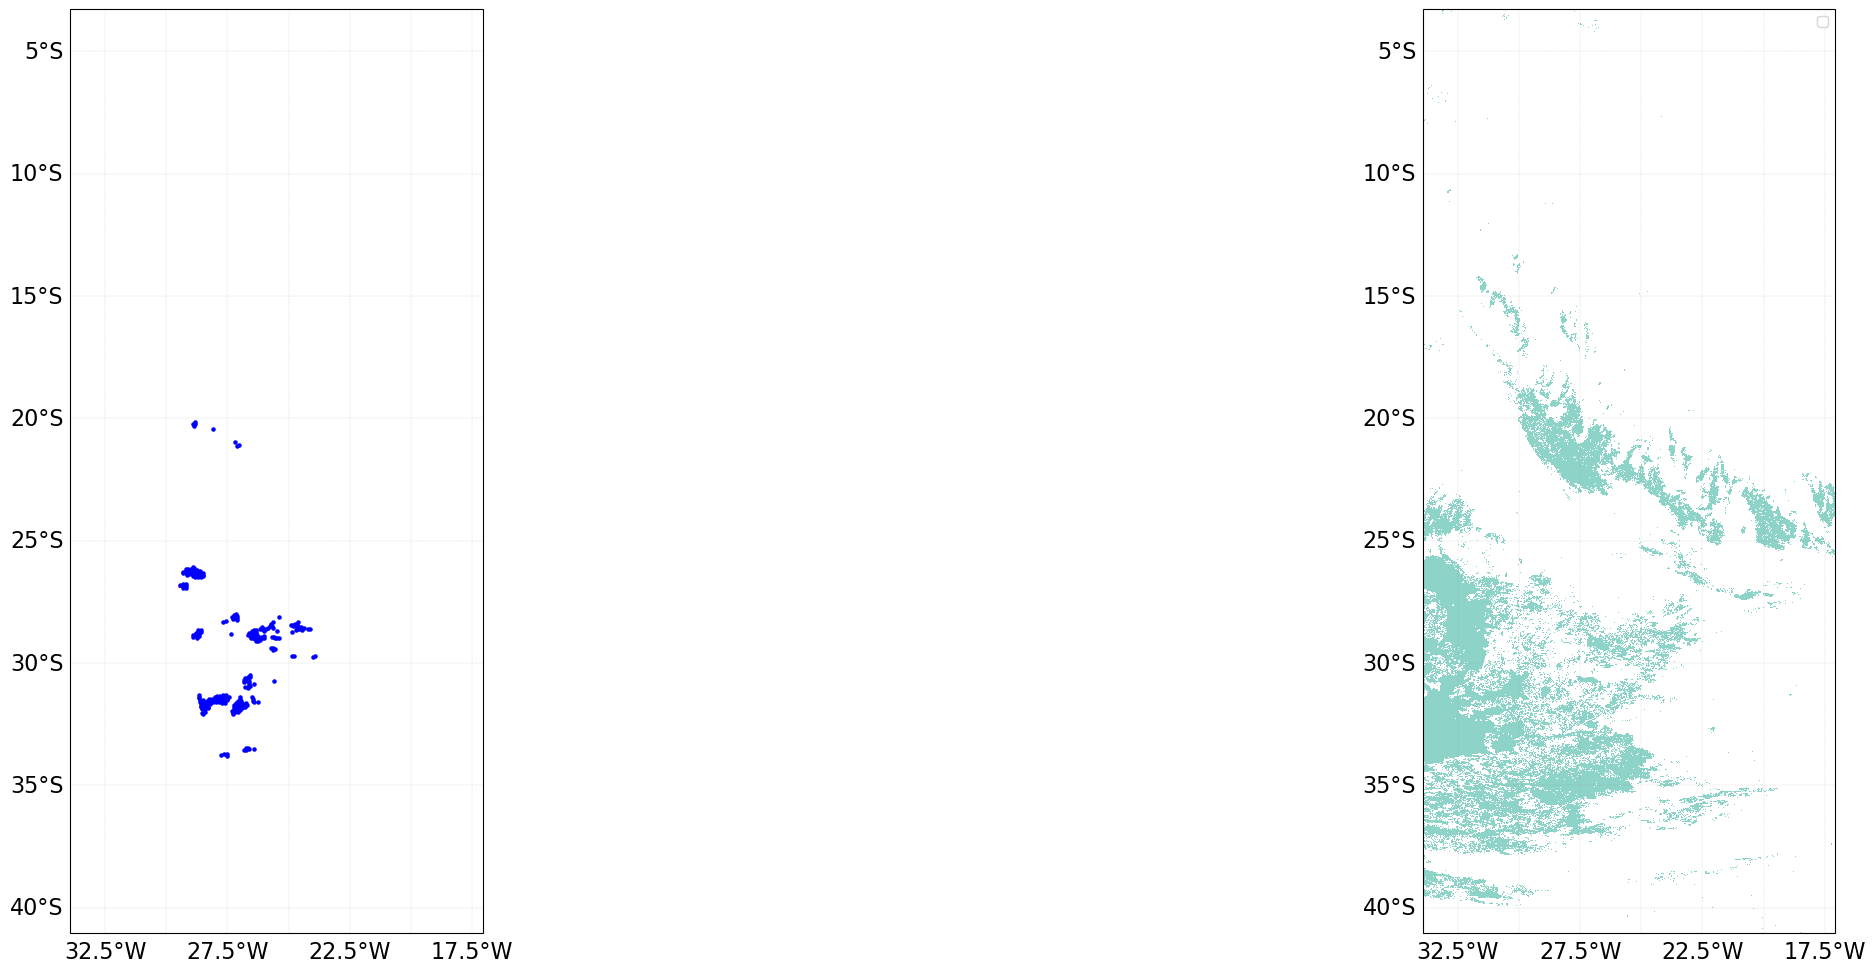

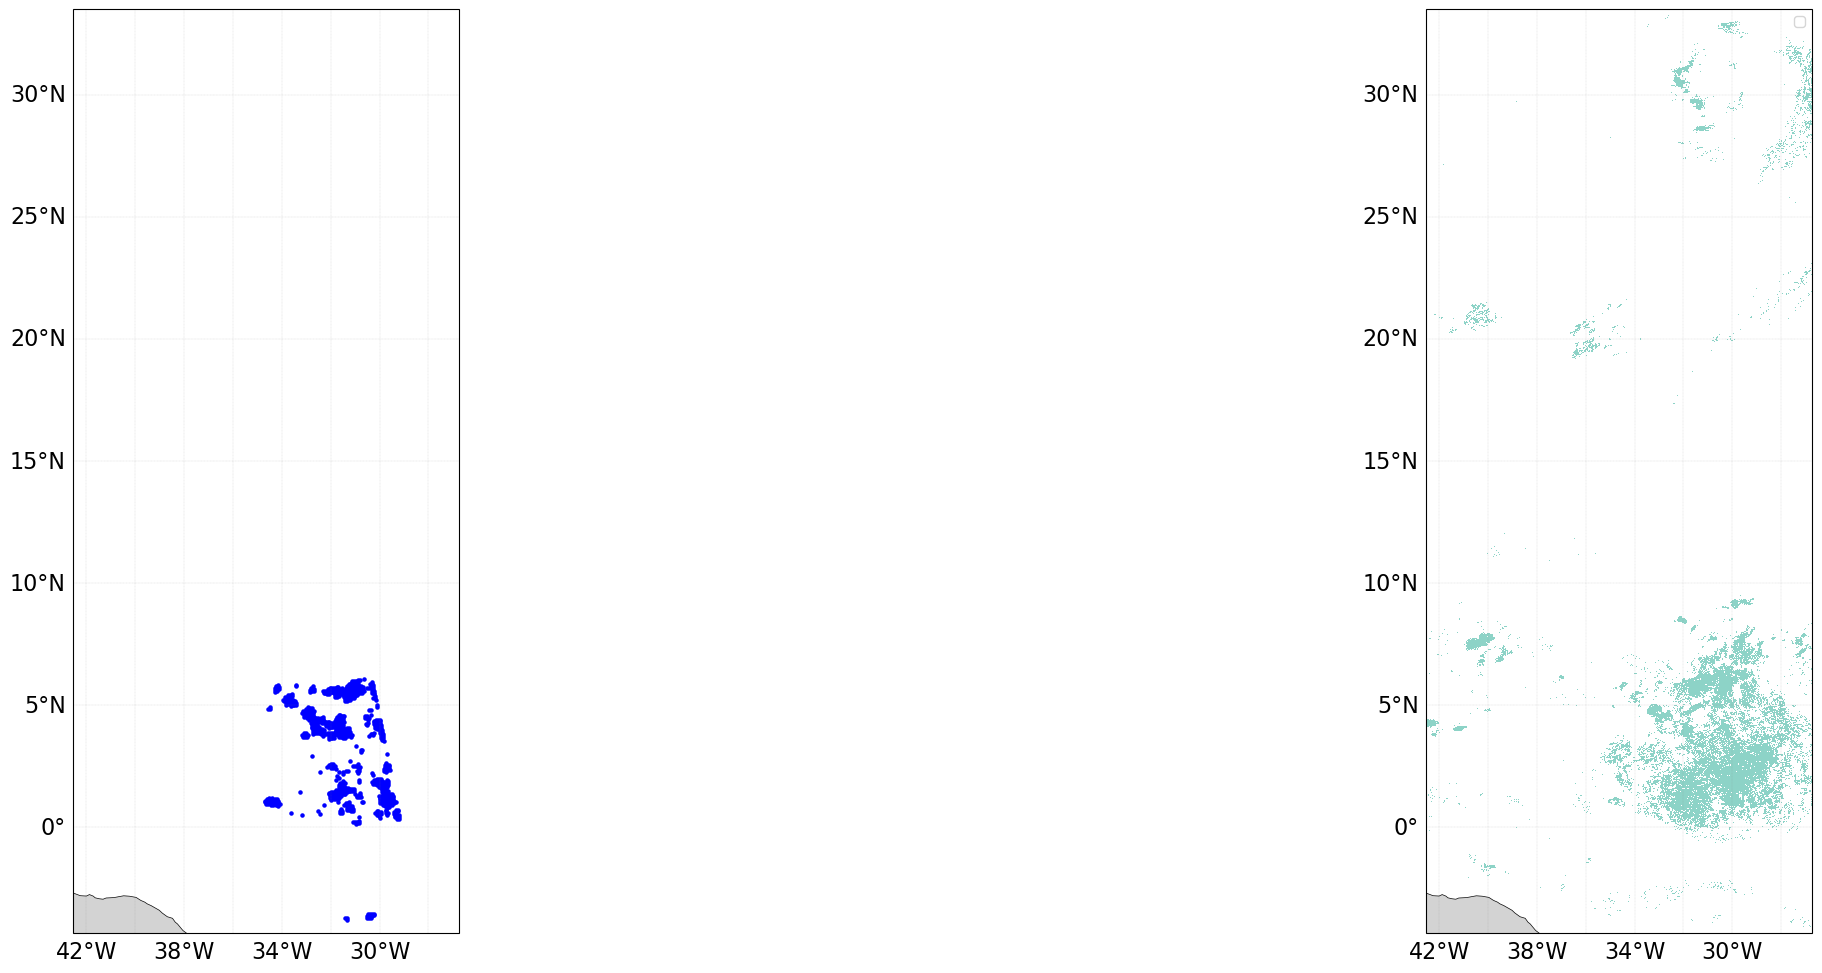

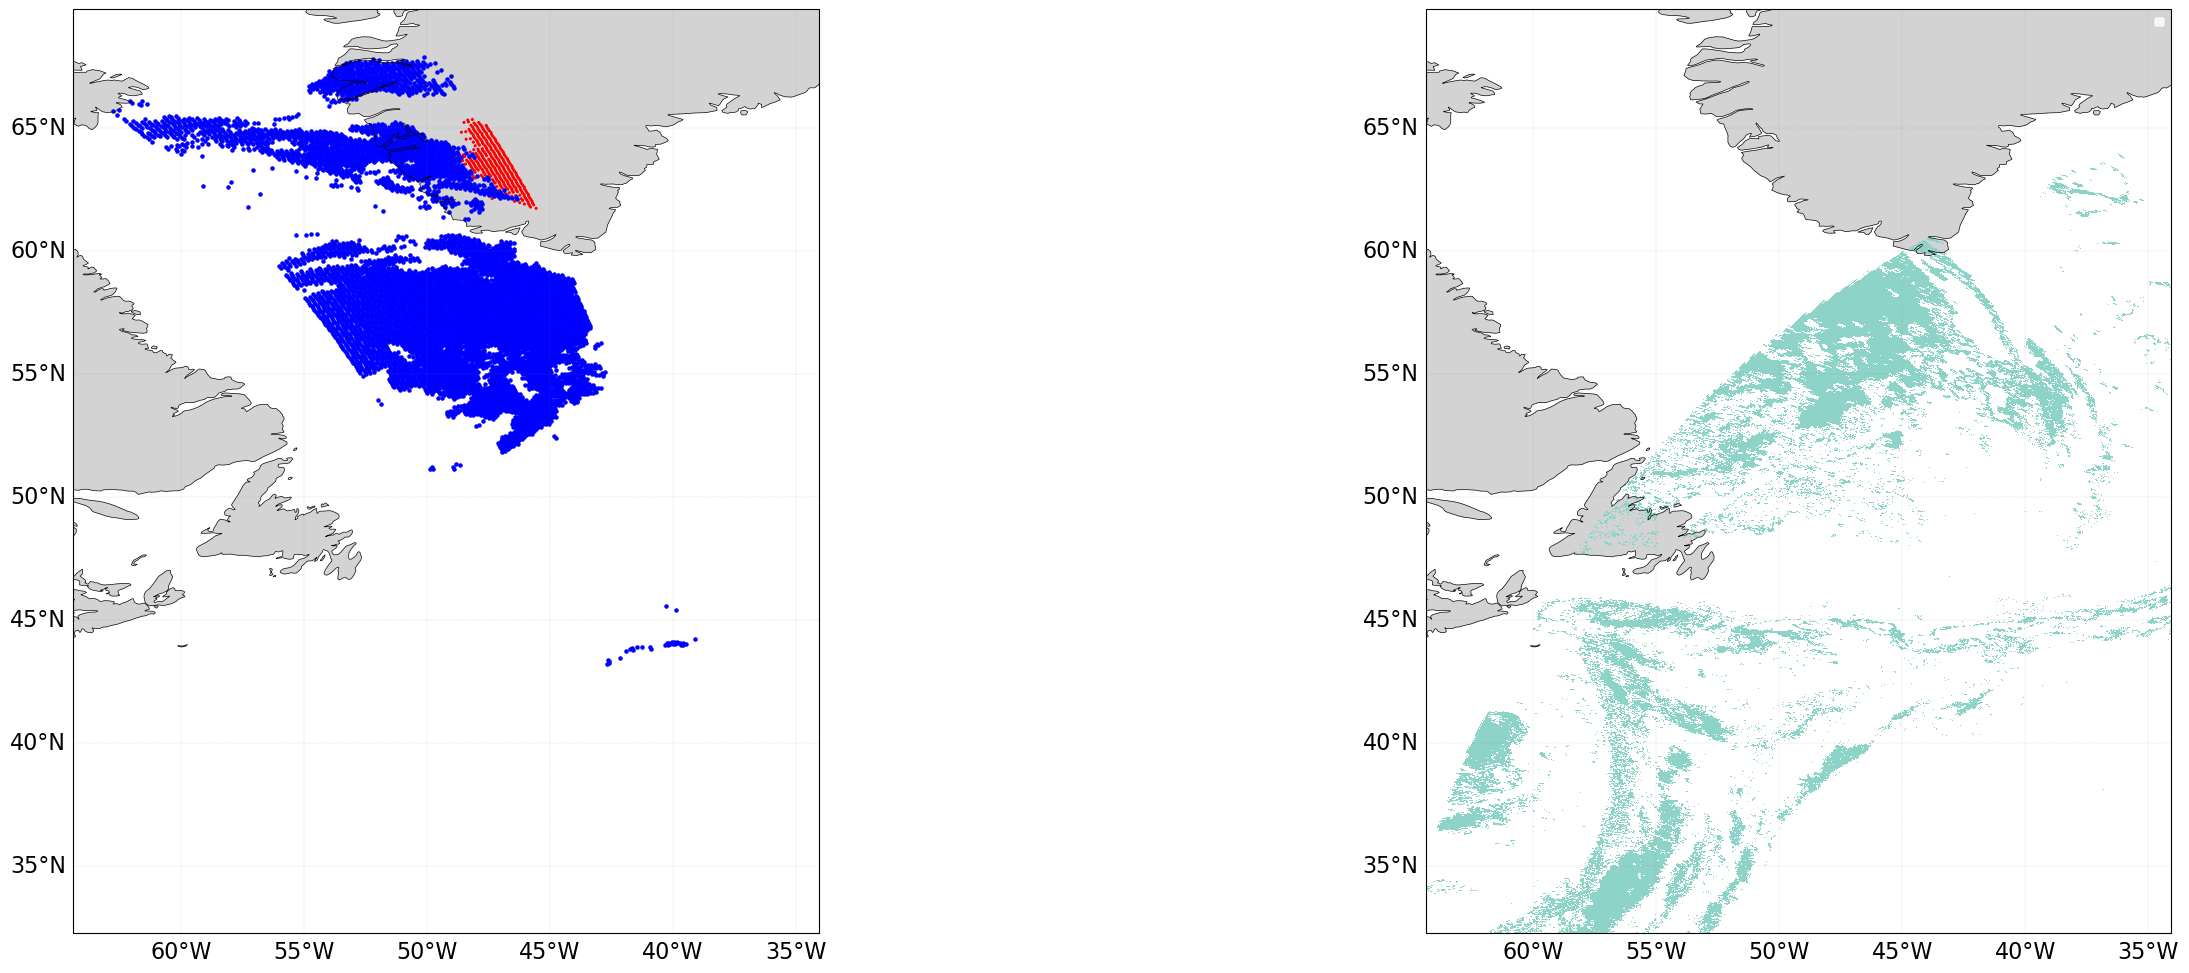

In [3]:

MTG_path = "../../../DataStorage/MTG/"

mtg_files = {}
for nc_file in glob.glob(MTG_path + "**/*.nc", recursive=True):
    folder = os.path.dirname(nc_file)
    t = parse_sensing_start(folder)
    if t is not None:
        mtg_files[t] = nc_file

mtg_times = sorted(mtg_files.keys())
mtg_times_arr = np.array(mtg_times)

scans = retrieval_ds.scan.values
step = 500

for i in range(0, len(scans), step):
    chunk = scans[i:i + step]
    mid_dt = pd.Timestamp(chunk[len(chunk) // 2]).to_pydatetime()

    mtg_file, mtg_t = get_closest_MTG(mid_dt)
    print(f"Chunk {i}-{i+len(chunk)-1} | mid: {mid_dt} | MTG: {mtg_t} | {mtg_file}")

    if not os.path.exists(mtg_file):
        print(f"Chunk {i}: MTG file not found for {mtg_dt}, skipping")
        continue

    ds_MTG = xr.open_dataset(mtg_file)

    nan_mask     = np.isnan(retrieval_ds.Ta_CloudSignal_AWS33_mean[i:i + step].values)
    bad_mask     = retrieval_ds.flag_bad_data[i:i + step].values != 0
    surface_mask = nan_mask & ~bad_mask
    cloud_mask_AWS33 = ~surface_mask & (retrieval_ds.Ta_CloudSignal_AWS33_mean[i:i + step].values > 1)


    fig = create_plot(cloud_mask_AWS33, retrieval_ds, ds_MTG, surface_mask, i, step)
    plt.savefig(
        f"../figures/retrievals_on_obs/MTG_comparison/cloud_filtered_and_MTG_{datetime_str}_{i}_{i+step}.png",
        dpi=200, bbox_inches="tight", facecolor="white")

    ds_MTG.close()

In [10]:
import xarray as xr

MTG_path = "../../../DataStorage/MTG/"
MTG_filename = MTG_path + "W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD--x-x---x_C_EUMT_20250604232719_L2PF_OPE_20250604231000_20250604232000_N__C_0140_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-2-OCA--FD------NC4E_C_EUMT_20250604232455_L2PF_OPE_20250604231000_20250604232000_N__C_0140_0000.nc"
ds_MTG = xr.open_dataset(MTG_filename)


In [11]:
ds.retrieved_cloud_phase.values

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int8)

In [12]:
ds["mtg_geos_projection"].attrs

{'long_name': 'MTG geostationary projection',
 'grid_mapping_name': 'geostationary',
 'perspective_point_height': np.float32(35786400.0),
 'semi_major_axis': np.float32(6378137.0),
 'semi_minor_axis': np.float32(6356752.0),
 'inverse_flattening': np.float32(298.25723),
 'latitude_of_projection_origin': np.float32(0.0),
 'longitude_of_projection_origin': np.float32(0.0),
 'sweep_angle_axis': 'y'}

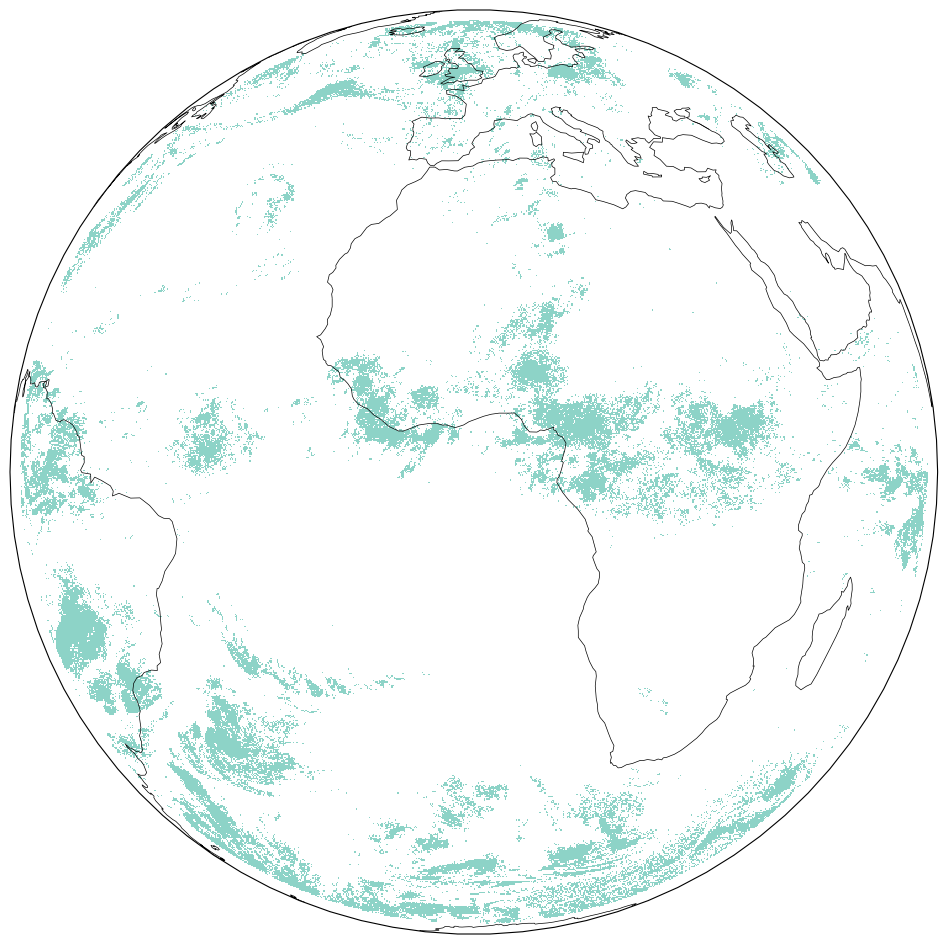

In [17]:
ds_MTG = xr.open_dataset(mtg_file)
masked_phase, extent, geo_proj = setup_mtg(ds_MTG)

fig, ax = plt.subplots(figsize=(12, 12),
                       subplot_kw={"projection": ccrs.Geostationary(
                           central_longitude=ds_MTG["mtg_geos_projection"].attrs["longitude_of_projection_origin"]
                       )})

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.imshow(masked_phase, origin="upper", extent=extent,
          transform=geo_proj, cmap="Set3", interpolation="none")
ax.set_global()
plt.show()

In [16]:
ds_MTG = xr.open_dataset(mtg_file)

# Print variable attributes - often contains flag meanings
print(ds_MTG["retrieved_cloud_phase"])
print()
print(ds_MTG["retrieved_cloud_phase"].attrs)

# See what unique values actually exist in the data
vals, counts = np.unique(ds_MTG["retrieved_cloud_phase"].values, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  value {v}: {c} pixels")


<xarray.DataArray 'retrieved_cloud_phase' (number_of_rows: 5568,
                                           number_of_columns: 5568)> Size: 31MB
[31002624 values with dtype=int8]
Coordinates:
    x        (number_of_columns) float32 22kB ...
    y        (number_of_rows) float32 22kB ...
Dimensions without coordinates: number_of_rows, number_of_columns
Attributes:
    long_name:     Retrieved cloud phase
    grid_mapping:  mtg_geos_projection

{'long_name': 'Retrieved cloud phase', 'grid_mapping': 'mtg_geos_projection'}
  value 0: 19979210 pixels
  value 1: 7735252 pixels
  value 2: 2353339 pixels
  value 3: 934823 pixels


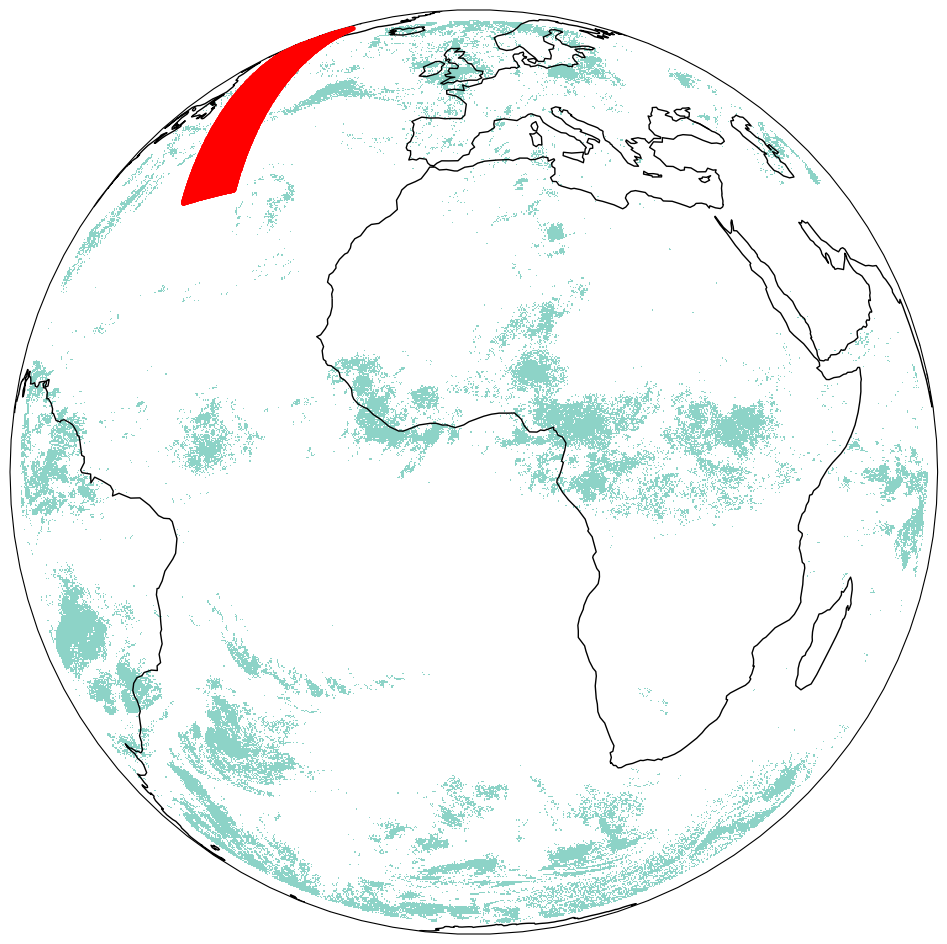

In [18]:
fig, ax = plt.subplots(figsize=(12, 12),
                       subplot_kw={"projection": ccrs.Geostationary(central_longitude=0)})
ax.coastlines()
masked_phase, extent, geo_proj = setup_mtg(ds_MTG)
ax.imshow(masked_phase, origin="upper", extent=extent,
          transform=geo_proj, cmap="Set3", interpolation="none")

# Overplot a chunk of your retrieval points
ax.scatter(
    retrieval_ds.longitude[i:i+step].values,
    retrieval_ds.latitude[i:i+step].values,
    s=5, c="red", transform=ccrs.PlateCarree(), zorder=5
)
plt.show()

In [19]:
retrieval_ds

<xarray.Dataset> Size: 187MB
Dimensions:                         (scan: 4995, fov: 88, quantile: 5,
                                     surface_type: 6, channel: 19)
Coordinates:
  * surface_type                    (surface_type) <U7 168B 'ocean' ... 'glac...
    latitude                        (scan, fov) float32 2MB ...
    longitude                       (scan, fov) float32 2MB ...
  * quantile                        (quantile) float32 20B 0.02 0.16 ... 0.98
  * channel                         (channel) <U5 380B 'AWS11' ... 'AWS44'
  * scan                            (scan) datetime64[ns] 40kB 2025-06-04T23:...
Dimensions without coordinates: fov
Data variables: (12/37)
    Ta_CloudSignal_AWS31_mean       (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS31_most_prob  (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS31_quantiles  (scan, fov, quantile) float32 9MB ...
    Ta_CloudSignal_AWS32_mean       (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS32_most_prob  (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS32_quantiles  (scan, fov, quantile) float32 9MB ...
    ...                              ...
    surface_type_fractions          (scan, fov, surface_type) float32 11MB ...
    tb                              (scan, fov, channel) float32 33MB ...
    model_variant                   (scan, fov) <U8 14MB ...
    l1b_index_scans                 (scan) uint32 20kB ...
    l1b_index_fovs                  (fov) uint32 352B ...
    flag_bad_data                   (scan, fov) uint8 440kB ...
Attributes:
    title:        Retrievals of cloud signal for the Arctic Weather Satellite...
    institution:  Chalmers University of Technology
    references:   n/a
    history:      Retrieval processing

In [20]:
ds_tmp = xr.open_dataset("../../../DataStorage/AWS/l2_cloud_signal/l2_cloud_signal_20000101000000_20251121115401.nc")

In [21]:
ds_tmp

<xarray.Dataset> Size: 167MB
Dimensions:                         (scan: 4476, fov: 88, quantile: 5,
                                     surface_type: 6, channel: 19)
Coordinates:
  * surface_type                    (surface_type) <U7 168B 'ocean' ... 'glac...
    latitude                        (scan, fov) float32 2MB ...
    longitude                       (scan, fov) float32 2MB ...
  * quantile                        (quantile) float32 20B 0.02 0.16 ... 0.98
  * channel                         (channel) <U5 380B 'AWS11' ... 'AWS44'
  * scan                            (scan) datetime64[ns] 36kB 2025-11-21T10:...
Dimensions without coordinates: fov
Data variables: (12/37)
    Ta_CloudSignal_AWS31_mean       (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS31_most_prob  (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS31_quantiles  (scan, fov, quantile) float32 8MB ...
    Ta_CloudSignal_AWS32_mean       (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS32_most_prob  (scan, fov) float32 2MB ...
    Ta_CloudSignal_AWS32_quantiles  (scan, fov, quantile) float32 8MB ...
    ...                              ...
    surface_type_fractions          (scan, fov, surface_type) float32 9MB ...
    tb                              (scan, fov, channel) float32 30MB ...
    model_variant                   (scan, fov) <U8 13MB ...
    l1b_index_scans                 (scan) uint32 18kB ...
    l1b_index_fovs                  (fov) uint32 352B ...
    flag_bad_data                   (scan, fov) uint8 394kB ...
Attributes:
    title:        Retrievals of cloud signal for the Arctic Weather Satellite...
    institution:  Chalmers University of Technology
    references:   n/a
    history:      Retrieval processing